In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip -q install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 29.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 3.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 41.6 MB/s eta 0:00:0000:0100:01m


In [3]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / stats
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Single cell
import scanpy as sc

# Settings
plt.style.use("default")
sns.set(style="whitegrid")
np.set_printoptions(suppress=True)

print("Libraries loaded successfully")

Libraries loaded successfully


# 1. Load Datasets

In [4]:
import os

print(os.listdir("/kaggle/input/myllia-training-data-means"))
print(os.listdir("/kaggle/input/myllia-training-cells"))
print(os.listdir("/kaggle/input/myllia-training-ground-truth"))

['training_data_means.csv']
['training_cells.h5ad']
['training_data_ground_truth_table.csv']


In [5]:
PATH_MEANS = "/kaggle/input/myllia-training-data-means/training_data_means.csv"
PATH_CELLS = "/kaggle/input/myllia-training-cells/training_cells.h5ad"
PATH_GT = "/kaggle/input/myllia-training-ground-truth/training_data_ground_truth_table.csv"

df_means = pd.read_csv(PATH_MEANS)
df_gt = pd.read_csv(PATH_GT)

adata = sc.read_h5ad(PATH_CELLS)

print("Means shape:", df_means.shape)
print("GT shape:", df_gt.shape)
print("Cells shape:", adata.shape)

Means shape: (81, 5128)
GT shape: (80, 10256)
Cells shape: (17882, 19226)


# 2. Construccion delta expression matrix

In [6]:
gene_cols = df_means.columns.drop("pert_symbol")

baseline = df_means[df_means["pert_symbol"] == "non-targeting"].iloc[0]
baseline_values = baseline[gene_cols].values

df_train = df_means[df_means["pert_symbol"] != "non-targeting"].reset_index(drop=True)

delta = df_train[gene_cols].values - baseline_values

delta_df = pd.DataFrame(delta, columns=gene_cols)
delta_df["pert_symbol"] = df_train["pert_symbol"]

print("Delta matrix shape:", delta.shape)

Delta matrix shape: (80, 5127)


# 3. Global Distribution Analysis

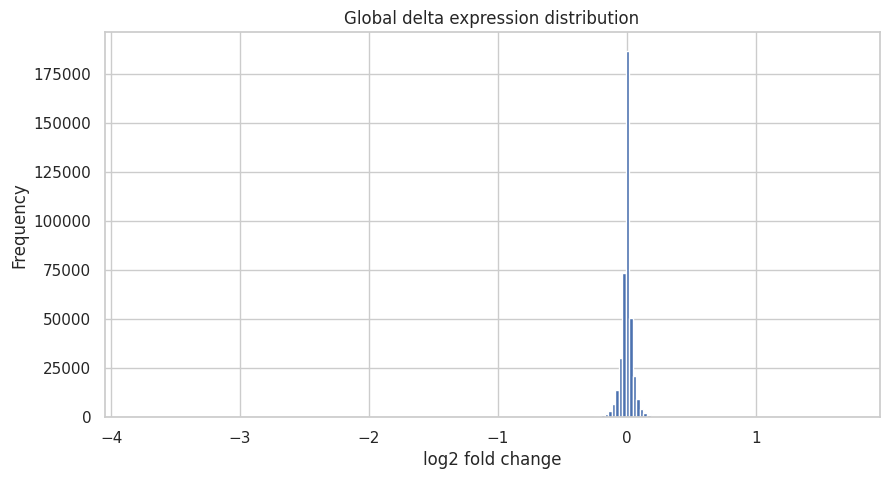

Mean delta: -0.0017655055617338473
Std delta: 0.056865307721545175
Median delta: -0.0004974314769368507


In [7]:
plt.figure(figsize=(10,5))

plt.hist(delta.flatten(), bins=200)

plt.title("Global delta expression distribution")
plt.xlabel("log2 fold change")
plt.ylabel("Frequency")

plt.show()

print("Mean delta:", delta.mean())
print("Std delta:", delta.std())
print("Median delta:", np.median(delta))

# 4. Sparsity analysis

In [8]:
# threshold biologico
threshold = 0.25

nonzero_fraction = (np.abs(delta) > threshold).mean()

print("Fraction responsive entries:", nonzero_fraction)

Fraction responsive entries: 0.004607957870099474


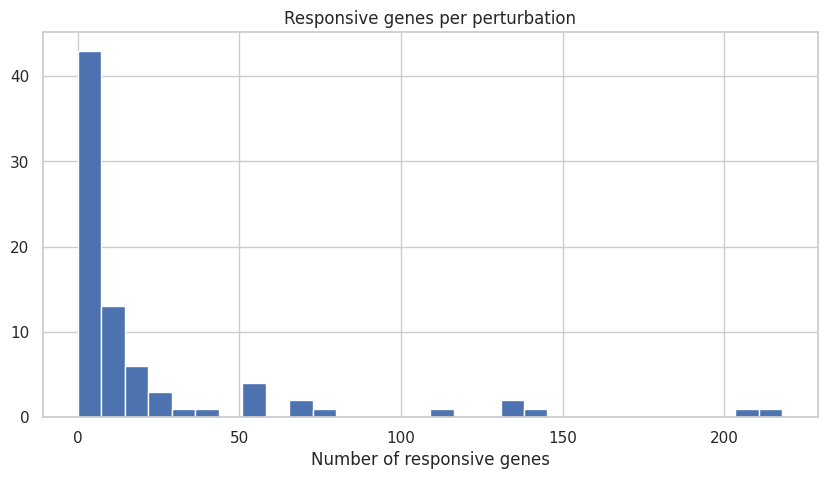

Mean responsive genes: 23.625


In [9]:
# por perturbacion
responsive_per_pert = (np.abs(delta) > threshold).sum(axis=1)

plt.figure(figsize=(10,5))

plt.hist(responsive_per_pert, bins=30)

plt.title("Responsive genes per perturbation")
plt.xlabel("Number of responsive genes")

plt.show()

print("Mean responsive genes:", responsive_per_pert.mean())

# 5. Perturbation Strength Analysis

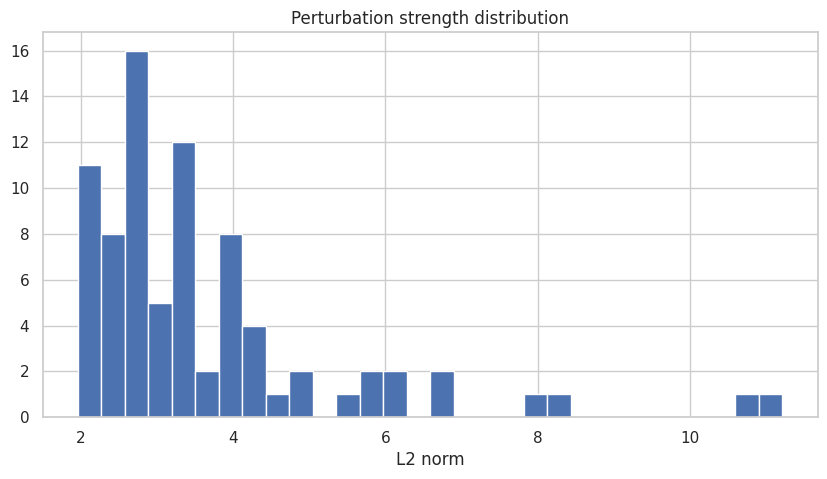

pert_symbol
LRPPRC     11.207621
TFAM       10.683284
KRAS        8.325447
SETD1A      7.888239
ALDOA       6.745194
STAG2       6.636584
EIF3H       6.275767
SLC39A6     6.200887
SSBP1       5.772721
INO80       5.705335
dtype: float64


In [24]:
delta = df_train[gene_cols].astype(float).values - baseline_values.astype(float)
pert_strength = np.linalg.norm(delta, axis=1)

plt.figure(figsize=(10,5))

plt.hist(pert_strength, bins=30)

plt.title("Perturbation strength distribution")
plt.xlabel("L2 norm")

plt.show()

# strongest perturbations
top_pert = pd.Series(
    pert_strength,
    index=df_train["pert_symbol"]
).sort_values(ascending=False)

print(top_pert.head(10))

# 6. Gene responsiveness analysis

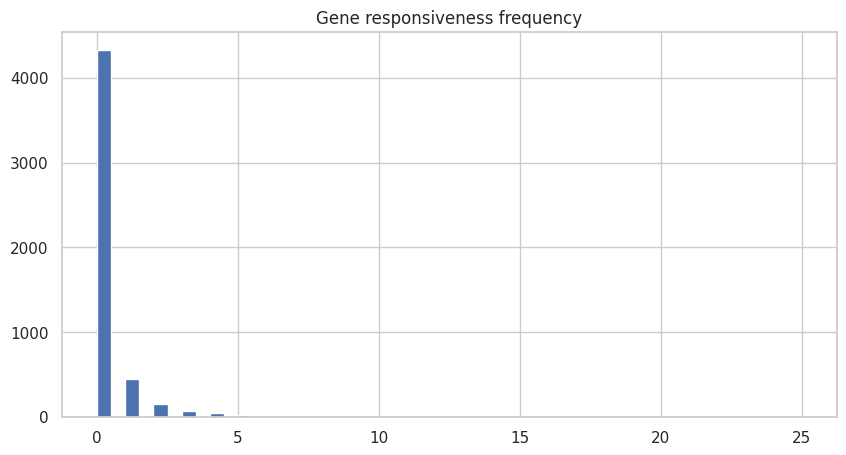

Top responsive genes:
MUC5AC      25
ALDH3A1     20
TPM1        19
MT2A        19
CXCL5       18
TRAM1       18
SERPINE1    18
DKK1        18
S100A4      16
PMEPA1      15
AKR1C1      15
AKAP12      11
H4C3        11
TOP2A       11
TUBA1B      10
GPX2        10
AKR1B10     10
C12orf75     9
KRT8         9
AGR2         9
dtype: int64


In [11]:
gene_responsiveness = (np.abs(delta) > threshold).sum(axis=0)

plt.figure(figsize=(10,5))

plt.hist(gene_responsiveness, bins=50)

plt.title("Gene responsiveness frequency")

plt.show()

top_genes = pd.Series(
    gene_responsiveness,
    index=gene_cols
).sort_values(ascending=False)

print("Top responsive genes:")
print(top_genes.head(20))

# 7. COrrelation Structure

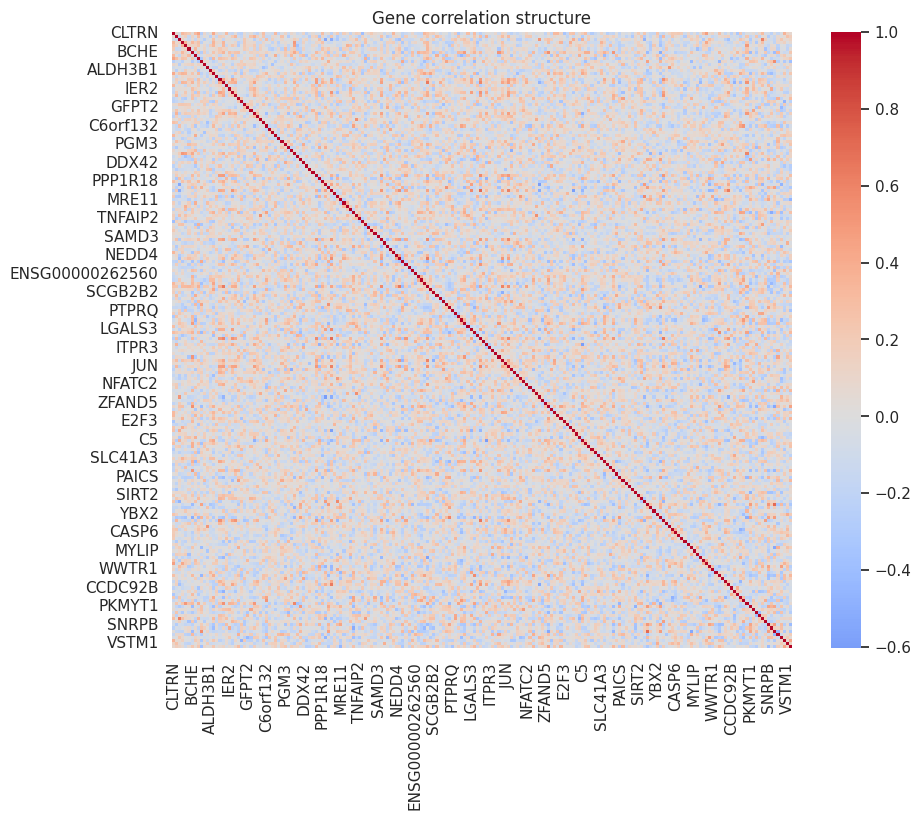

In [12]:
sample_genes = np.random.choice(gene_cols, size=200, replace=False)

corr = delta_df[sample_genes].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Gene correlation structure")

plt.show()

# 8. PCA analysis

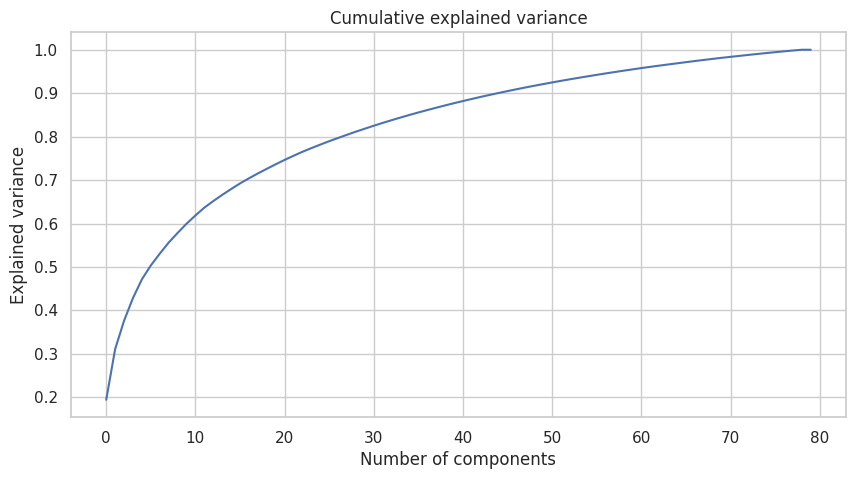

Components needed for 90% variance: 44


In [13]:
pca = PCA()

pca.fit(delta)

explained = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))

plt.plot(np.cumsum(explained))

plt.title("Cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Explained variance")

plt.show()

# cuantos componentes explican 90%
n90 = np.argmax(np.cumsum(explained) >= 0.90)

print("Components needed for 90% variance:", n90)

# 9. Perturbation similarity

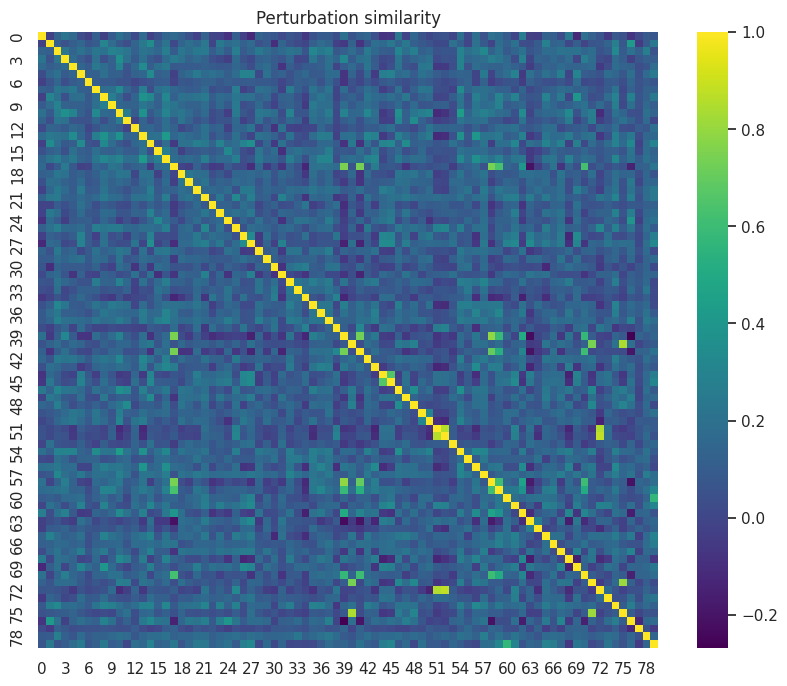

In [14]:
sim = cosine_similarity(delta)

plt.figure(figsize=(10,8))

sns.heatmap(sim, cmap="viridis")

plt.title("Perturbation similarity")

plt.show()

# 10. Ground truth weights analysis

In [17]:
print(df_gt.columns)

Index(['pert_id', 'A1BG', 'A1CF', 'AADAC', 'AAK1', 'AARS1', 'AASS', 'ABCA1',
       'ABCA12', 'ABCA5',
       ...
       'w_ZPBP', 'w_ZRANB3', 'w_ZSCAN18', 'w_ZSCAN31', 'w_ZSWIM5', 'w_ZSWIM6',
       'w_ZSWIM7', 'w_ZWINT', 'w_ZYX', 'baseline_wmae'],
      dtype='object', length=10256)


In [20]:
weight_cols = [col for col in df_gt.columns if "weight" in col.lower()]

if len(weight_cols) > 0:

    weights = df_gt[weight_cols].values.flatten()

    plt.figure(figsize=(10,5))

    plt.hist(weights, bins=100)

    plt.title("Gene weight distribution")

    plt.show()

    print("Mean weight:", weights.mean())

# 11. SIngle Cell variance analysis

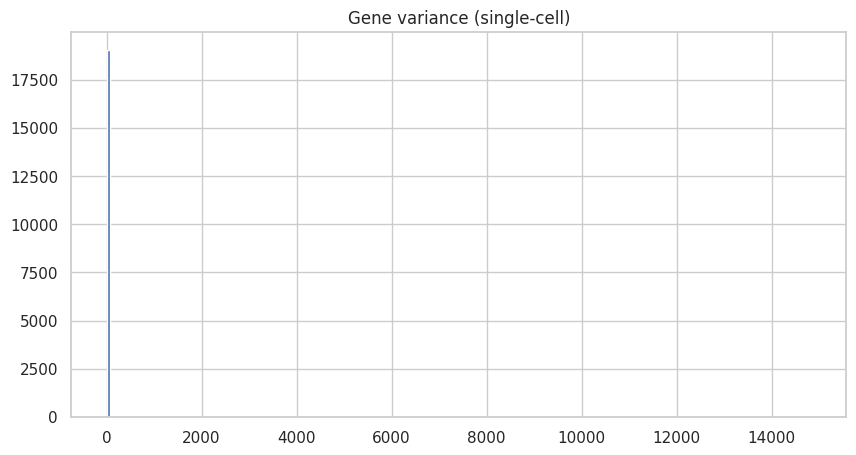

Top variable genes:
FTL        14833.539656
MT-CO1     13361.931907
MT-CO2      9005.753308
MT-CO3      5841.582672
FTH1        4833.052570
RPLP1       4244.532772
ACTB        3926.176153
RPL28       3126.779142
RPS19       3064.507014
ALDH1A1     3029.307015
TMSB10      2702.015383
KRT18       2694.029411
S100A6      2532.164897
RPS16       2464.928301
GAPDH       2375.603160
RPL10       2280.736018
AKR1C2      2216.224376
RPL41       1989.603610
ACTG1       1926.300024
TMSB4X      1903.358079
dtype: float64


In [21]:
# compute gene variance
gene_var = np.var(adata.X.toarray(), axis=0)

plt.figure(figsize=(10,5))

plt.hist(gene_var, bins=200)

plt.title("Gene variance (single-cell)")

plt.show()

# top variable genes
var_series = pd.Series(
    gene_var,
    index=adata.var_names
).sort_values(ascending=False)

print("Top variable genes:")
print(var_series.head(20))

# 12. PCA on single cell

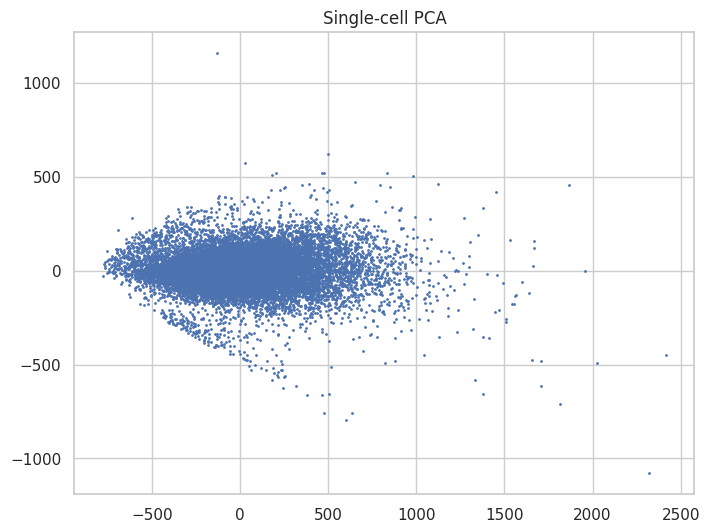

In [22]:
sc.tl.pca(adata)

plt.figure(figsize=(8,6))

plt.scatter(
    adata.obsm["X_pca"][:,0],
    adata.obsm["X_pca"][:,1],
    s=1
)

plt.title("Single-cell PCA")

plt.show()

In [25]:
print("SUMMARY")

print("Sparsity:", nonzero_fraction)

print("Mean perturbation strength:", pert_strength.mean())

print("Max perturbation strength:", pert_strength.max())

print("Effective dimensionality (90%):", n90)

print("Number of genes:", delta.shape[1])

print("Number of perturbations:", delta.shape[0])

SUMMARY
Sparsity: 0.004607957870099474
Mean perturbation strength: 3.66871960235501
Max perturbation strength: 11.207620506180607
Effective dimensionality (90%): 44
Number of genes: 5127
Number of perturbations: 80
